## From Uplift Modeling to Counterfactual Explanations

### Abstract
This post evaluates advanced CATE (Conditional Average Treatment Effect) estimation approaches on a public experimental dataset, with a focus on how different methods balance flexibility, interpretability, and decision usefulness. While many models can recover heterogeneous effects, their behavior differs significantly when used for segment-level targeting and counterfactual reasoning.

---

This post explores advanced CATE estimation approaches on the LaLonde job training experiment, a well-known randomized dataset, focusing on how methods move beyond uplift ranking toward interpretable counterfactual effects.

The emphasis is not just on estimation accuracy, but on how these approaches differ in stability, interpretability, and practical usefulness for decision-making. In particular, we examine how model choice influences which segments appear actionable and how reliable those signals are.

We focus on:

- how different methods capture heterogeneous treatment effects  
- trade-offs between flexibility and interpretability  
- stability of estimates across segments  
- how uncertainty influences decision-making  
- when counterfactual explanations add value beyond uplift ranking  

---

## Framing and deviations from standard setups

Most illustrative examples of CATE estimation focus on structured marketing datasets and specific modeling pipelines.

Here, we instead use a randomized experimental dataset to examine how these methods behave under cleaner identification conditions, and to highlight differences that are often less visible in more curated setups.

The LaLonde data consists of:
- a **binary treatment** setting (`treat` vs `control`)  
- a **continuous outcome** (`re78`, earnings in 1978)

The analysis follows a standard causal ML workflow, but is adapted to emphasize practical behavior, model trade-offs, and decision-relevant insights across methods.

> **Important:** the final counterfactual section is intended to illustrate model behavior and interpretation, not to recover ground-truth causal effects. This distinction is central to how these methods should be used in practice.

---

## Background and references

This work is informed by standard approaches to CATE estimation in the causal inference literature. In particular, ideas related to uplift modeling and counterfactual reasoning are discussed in:

- Molak, A. *Causal Inference and Discovery in Python*

The analysis here extends these ideas to a different dataset and focuses on practical behavior and decision-making implications.


In [1]:

# If you are running this notebook in a fresh environment, uncomment the next line.
!pip install -q econml dowhy dice-ml lightgbm rdatasets

In [2]:

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMRegressor, LGBMClassifier

# EconML estimators
from econml.metalearners import SLearner, TLearner, XLearner
from econml.dr import DRLearner
from econml.dml import LinearDML, CausalForestDML

np.random.seed(42)
pd.set_option("display.max_columns", 200)

## 1. Load a different public dataset: LaLonde

The LaLonde dataset is a randomized job-training study and is widely used in causal inference.
We will download a public CSV mirror from the `Rdatasets` repository.


In [3]:

url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/MatchIt/lalonde.csv"
df = pd.read_csv(url)

# Keep only the useful columns
df = df.drop(columns=["rownames"], errors="ignore")

# Treatment and outcome naming consistent with the chapter
df = df.rename(columns={"treat": "treatment", "re78": "outcome"})

df.head()

,treatment,age,educ,race,married,nodegree,re74,re75,outcome
0,1,37,11,black,1,1,0.0,0.0,9930.0460
1,1,22,9,hispan,0,1,0.0,0.0,3595.8940
2,1,30,12,black,0,0,0.0,0.0,24909.4500
3,1,27,11,black,0,1,0.0,0.0,7506.1460
4,1,33,8,black,0,1,0.0,0.0,289.7899


### Data dictionary (quick version)

- `treatment`: whether the person received job training
- `outcome`: earnings in 1978
- `age`, `educ`: age and education
- `black`, `hispan`, `married`, `nodegree`: demographic indicators
- `re74`, `re75`: earnings in prior years

The experiment is randomized, which means treatment should **not** be predictable from covariates if randomization worked well.


In [4]:

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
treatment,614.0,NaN,NaN,NaN,0.301303,0.459198,0.0,0.0,0.0,1.0,1.0
age,614.0,NaN,NaN,NaN,27.363192,9.881187,16.0,20.0,25.0,32.0,55.0
educ,614.0,NaN,NaN,NaN,10.26873,2.628325,0.0,9.0,11.0,12.0,18.0
race,614,3,white,299,NaN,NaN,NaN,NaN,NaN,NaN,NaN
married,614.0,NaN,NaN,NaN,0.415309,0.493177,0.0,0.0,0.0,1.0,1.0
nodegree,614.0,NaN,NaN,NaN,0.630293,0.483119,0.0,0.0,1.0,1.0,1.0
re74,614.0,NaN,NaN,NaN,4557.546569,6477.964479,0.0,0.0,1042.33,7888.49825,35040.07
re75,614.0,NaN,NaN,NaN,2184.938207,3295.679043,0.0,0.0,601.5484,3248.9875,25142.24
outcome,614.0,NaN,NaN,NaN,6792.834483,7470.730792,0.0,238.283425,4759.0185,10893.5925,60307.93


## 2. Build feature, treatment, and outcome matrices


In [5]:

X = df.drop(columns=["treatment", "outcome"])
X = pd.get_dummies(X,drop_first=True)
T = df["treatment"].astype(int)
Y = df["outcome"].astype(float)

print("Rows:", len(df))
print("Treatment rate:", T.mean().round(4))
print("Average outcome:", Y.mean().round(2))
X.head()

Rows: 614
Treatment rate: 0.3013
Average outcome: 6792.83


,age,educ,married,nodegree,re74,re75,race_hispan,race_white
0,37,11,1,1,0.0,0.0,False,False
1,22,9,0,1,0.0,0.0,True,False
2,30,12,0,0,0.0,0.0,False,False
3,27,11,0,1,0.0,0.0,False,False
4,33,8,0,1,0.0,0.0,False,False


Rows: 614
    Treatment rate: 0.3013
    Average outcome: 6792.83
    


## 3. Randomization sanity check

 We first ask:

> Can observed covariates predict treatment?

If treatment assignment is really random, a model should not do much better than naive guessing.


In [6]:

# Check marginal treatment distribution
treatment_dist = T.value_counts(normalize=True).sort_index()
treatment_dist

treatment
0    0.698697
1    0.301303
Name: proportion, dtype: float64

treatment
    0    0.698697
    1    0.301303
    Name: proportion, dtype: float64


In [7]:

X_train_eda, X_test_eda, T_train_eda, T_test_eda = train_test_split(
    X, T, test_size=0.5, random_state=42, stratify=T
)

clf_eda = LGBMClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    verbosity=-1,
    random_state=42
)
clf_eda.fit(X_train_eda, T_train_eda)

T_pred_eda = clf_eda.predict(X_test_eda)
eda_accuracy = accuracy_score(T_test_eda, T_pred_eda)
eda_accuracy

$\displaystyle 0.820846905537459$


For a binary treatment, the naive benchmark is roughly the larger class probability.
Now we simulate what a **random classifier** would achieve if it only respected the treatment marginal.


In [8]:

p1 = T.mean()
n_test = len(T_test_eda)

random_scores = []
for _ in range(10000):
    random_pred = np.random.binomial(1, p1, size=n_test)
    random_scores.append((random_pred == T_test_eda.to_numpy()).mean())

ci_low, ci_high = np.quantile(random_scores, [0.025, 0.975])

print("Observed treatment-prediction accuracy :", round(eda_accuracy, 4))
print("95% empirical random-accuracy interval :", (round(ci_low, 4), round(ci_high, 4)))

Observed treatment-prediction accuracy : 0.8208
95% empirical random-accuracy interval : (np.float64(0.5277), np.float64(0.6319))


Observed treatment-prediction accuracy : 0.8208
    95% empirical random-accuracy interval : (np.float64(0.5277), np.float64(0.6319))


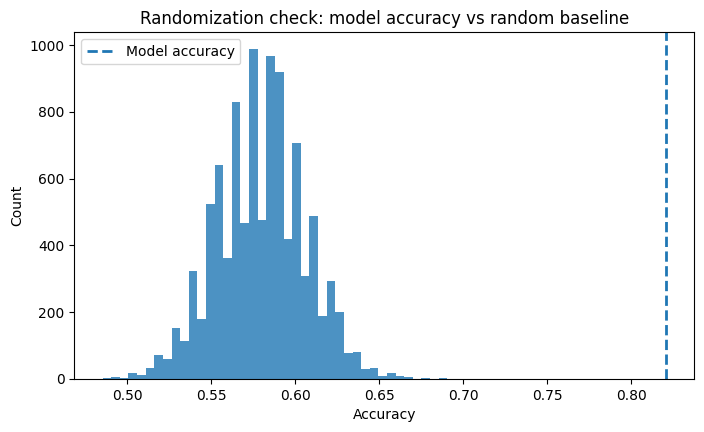

In [9]:

plt.figure(figsize=(8, 4.5))
plt.hist(random_scores, bins=40, alpha=0.8)
plt.axvline(eda_accuracy, linestyle="--", linewidth=2, label="Model accuracy")
plt.title("Randomization check: model accuracy vs random baseline")
plt.xlabel("Accuracy")
plt.ylabel("Count")
plt.legend()
plt.show()

If the model accuracy falls near the random baseline, that is good news:
the observed covariates do not strongly predict treatment, which is what we hope to see in a randomized experiment.

## 4. Train / test split for uplift modeling

We create a separate train and test split.
Because experimental datasets can still be small in terms of **effective signal**, it is useful to keep a large test set.


In [10]:

X_train, X_test, y_train, y_test, T_train, T_test = train_test_split(
    X, Y, T, test_size=0.5, random_state=42, stratify=T
)

print("Train rows:", len(X_train))
print("Test rows :", len(X_test))
print("Treatment rate train:", T_train.mean().round(4))
print("Treatment rate test :", T_test.mean().round(4))

Train rows: 307
Test rows : 307
Treatment rate train: 0.3029
Treatment rate test : 0.2997


Train rows: 307
    Test rows : 307
    Treatment rate train: 0.3029
    Treatment rate test : 0.2997
    

## 5. Helper functions and model definitions

We now implement a standard set of CATE estimators to compare them:

- S-Learner
- T-Learner
- X-Learner
- DR-Learner
- Linear DML
- Causal Forest DML

For consistency, we use LightGBM as the main base learner, just like the book often does.


In [11]:

def create_regressor():
    return LGBMRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        verbosity=-1,
        random_state=42
    )

def create_classifier():
    return LGBMClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        verbosity=-1,
        random_state=42
    )

s_learner = SLearner(overall_model=create_regressor())

t_learner = TLearner(models=[create_regressor(), create_regressor()])

x_learner = XLearner(
    models=[create_regressor(), create_regressor()],
    cate_models=[create_regressor(), create_regressor()],
)

dr_learner = DRLearner(
    model_propensity=LogisticRegression(max_iter=2000),
    model_regression=create_regressor(),
    model_final=create_regressor(),
    cv=5,
)

linear_dml = LinearDML(
    model_y=create_regressor(),
    model_t=create_classifier(),
    discrete_treatment=True,
    cv=5,
    random_state=42,
)

causal_forest = CausalForestDML(
    model_y=create_regressor(),
    model_t=create_classifier(),
    discrete_treatment=True,
    cv=5,
    random_state=42,
)

models = {
    "SLearner": s_learner,
    "TLearner": t_learner,
    "XLearner": x_learner,
    "DRLearner": dr_learner,
    "LinearDML": linear_dml,
    "CausalForestDML": causal_forest,
}

## 6. Fit all models and compare training time

 Exact run times will vary by machine, but relative ordering is the main idea.


In [12]:

fit_times = {}

for model_name, model in models.items():
    start = time.time()
    if model_name in {"LinearDML", "CausalForestDML"}:
        model.fit(Y=y_train, T=T_train, X=X_train)
    else:
        model.fit(Y=y_train, T=T_train, X=X_train)
    stop = time.time()
    fit_times[model_name] = stop - start
    print(f"{model_name:<16} fitted in {fit_times[model_name]:.3f} seconds")

SLearner         fitted in 0.065 seconds
TLearner         fitted in 0.077 seconds
XLearner         fitted in 0.169 seconds
DRLearner        fitted in 4.611 seconds
LinearDML        fitted in 0.625 seconds
CausalForestDML  fitted in 0.942 seconds


SLearner         fitted in 0.052 seconds
    TLearner         fitted in 0.088 seconds
    XLearner         fitted in 0.129 seconds
    DRLearner        fitted in 2.457 seconds
    LinearDML        fitted in 0.371 seconds
    CausalForestDML  fitted in 0.583 seconds


In [13]:

timing_df = pd.DataFrame({
    "Model": list(fit_times.keys()),
    "TimeSeconds": list(fit_times.values())
}).sort_values("TimeSeconds")

baseline = timing_df["TimeSeconds"].min()
timing_df["RelativeToFastest"] = (timing_df["TimeSeconds"] / baseline).round(1)

timing_df

,Model,TimeSeconds,RelativeToFastest
0,SLearner,0.065049,1.0
1,TLearner,0.076759,1.2
2,XLearner,0.169344,2.6
4,LinearDML,0.624617,9.6
5,CausalForestDML,0.941933,14.5
3,DRLearner,4.610782,70.9


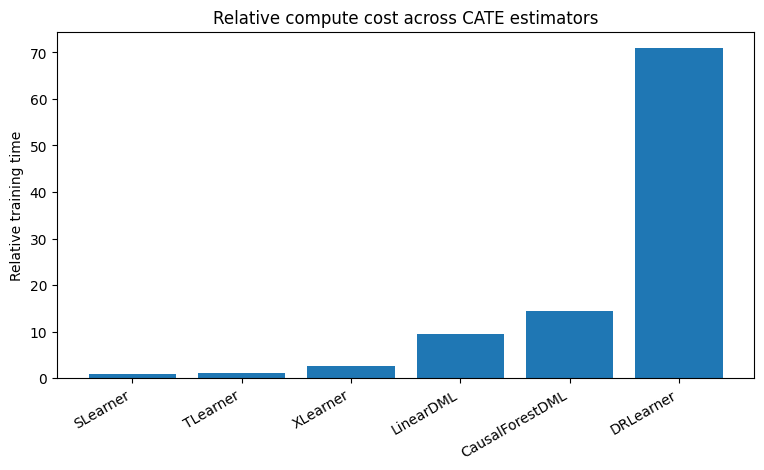

In [14]:

plt.figure(figsize=(9, 4.5))
plt.bar(timing_df["Model"], timing_df["RelativeToFastest"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Relative training time")
plt.title("Relative compute cost across CATE estimators")
plt.show()

## 7. Get CATE / uplift predictions

For a binary treatment experiment, the predicted uplift is simply the estimated effect of going from control (`T0=0`) to treatment (`T1=1`).


In [15]:

def cate_predict(model, X_data):
    return model.effect(X_data)

cate_train = {name: cate_predict(model, X_train) for name, model in models.items()}
cate_test  = {name: cate_predict(model, X_test)  for name, model in models.items()}

pd.DataFrame({k: np.asarray(v).ravel()[:5] for k, v in cate_test.items()})

,SLearner,TLearner,XLearner,DRLearner,LinearDML,CausalForestDML
0,66.838847,6255.915004,3166.608390,3546.645036,5768.924299,3262.998457
1,-137.971741,-4166.883389,-616.743227,-4107.529289,8828.882399,884.823406
2,1596.118279,2900.016716,474.007860,-5306.252895,3452.218217,1884.682510
3,539.519164,294.686420,1326.560882,101.825536,1065.778789,950.812086
4,494.817338,4926.474853,2585.430688,6747.790039,-353.910100,207.545285


## 8. Uplift by decile

This is one of the main ideas of the analysis.

### Intuition
1. Score each unit by predicted uplift.
2. Sort from highest predicted uplift to lowest.
3. Split into 10 bins (deciles).
4. Inside each decile, estimate the **observed uplift**:
 Observed uplift = E[Y | T = 1] − E[Y | T = 0]
5. A good model should show **higher observed uplift in top deciles** than in lower deciles.


In [16]:

def uplift_by_decile(y, t, uplift, n_bins=10):
    temp = pd.DataFrame({
        "y": np.asarray(y),
        "t": np.asarray(t).astype(int),
        "uplift": np.asarray(uplift).ravel()
    }).sort_values("uplift", ascending=False).reset_index(drop=True)

    temp["decile"] = pd.qcut(
        np.arange(len(temp)),
        q=n_bins,
        labels=False,
        duplicates="drop"
    )

    rows = []
    for decile, group in temp.groupby("decile"):
        treated = group.loc[group["t"] == 1, "y"]
        control = group.loc[group["t"] == 0, "y"]
        uplift_obs = treated.mean() - control.mean() if len(treated) and len(control) else np.nan
        rows.append({
            "decile": int(decile),
            "n": len(group),
            "treated_n": len(treated),
            "control_n": len(control),
            "observed_uplift": uplift_obs
        })
    return pd.DataFrame(rows)

In [17]:

def plot_uplift_by_decile(decile_df, title):
    plt.figure(figsize=(8, 4.5))
    plt.bar(decile_df["decile"], decile_df["observed_uplift"])
    plt.axhline(0, linewidth=1)
    plt.title(title)
    plt.xlabel("Decile (0 = highest predicted uplift)")
    plt.ylabel("Observed uplift")
    plt.show()

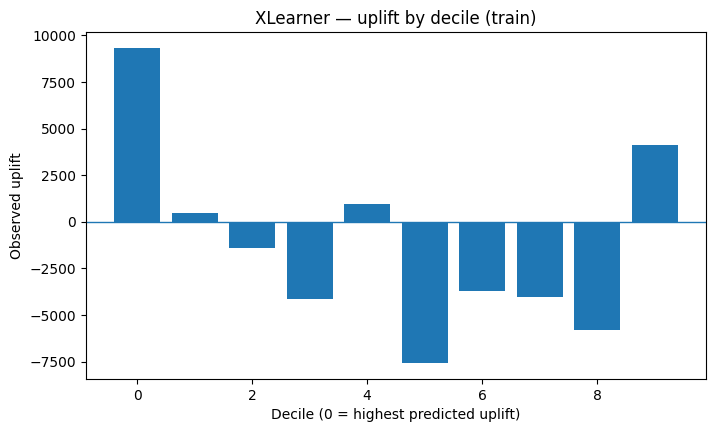

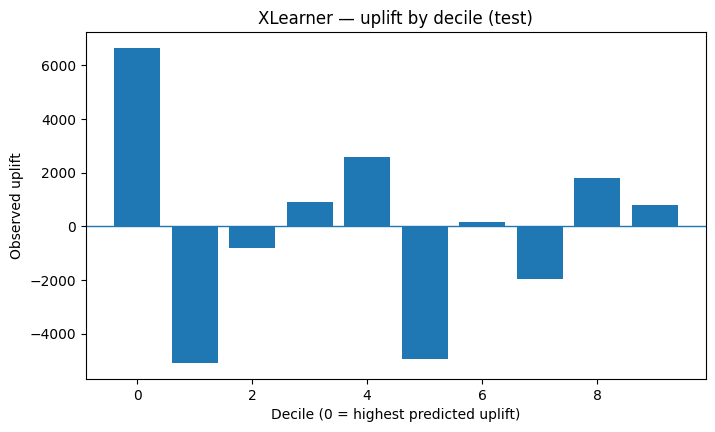

In [18]:

# Example: one model on train and test
example_train = uplift_by_decile(y_train, T_train, cate_train["XLearner"])
example_test  = uplift_by_decile(y_test,  T_test,  cate_test["XLearner"])

plot_uplift_by_decile(example_train, "XLearner — uplift by decile (train)")
plot_uplift_by_decile(example_test, "XLearner — uplift by decile (test)")

### Compare all models


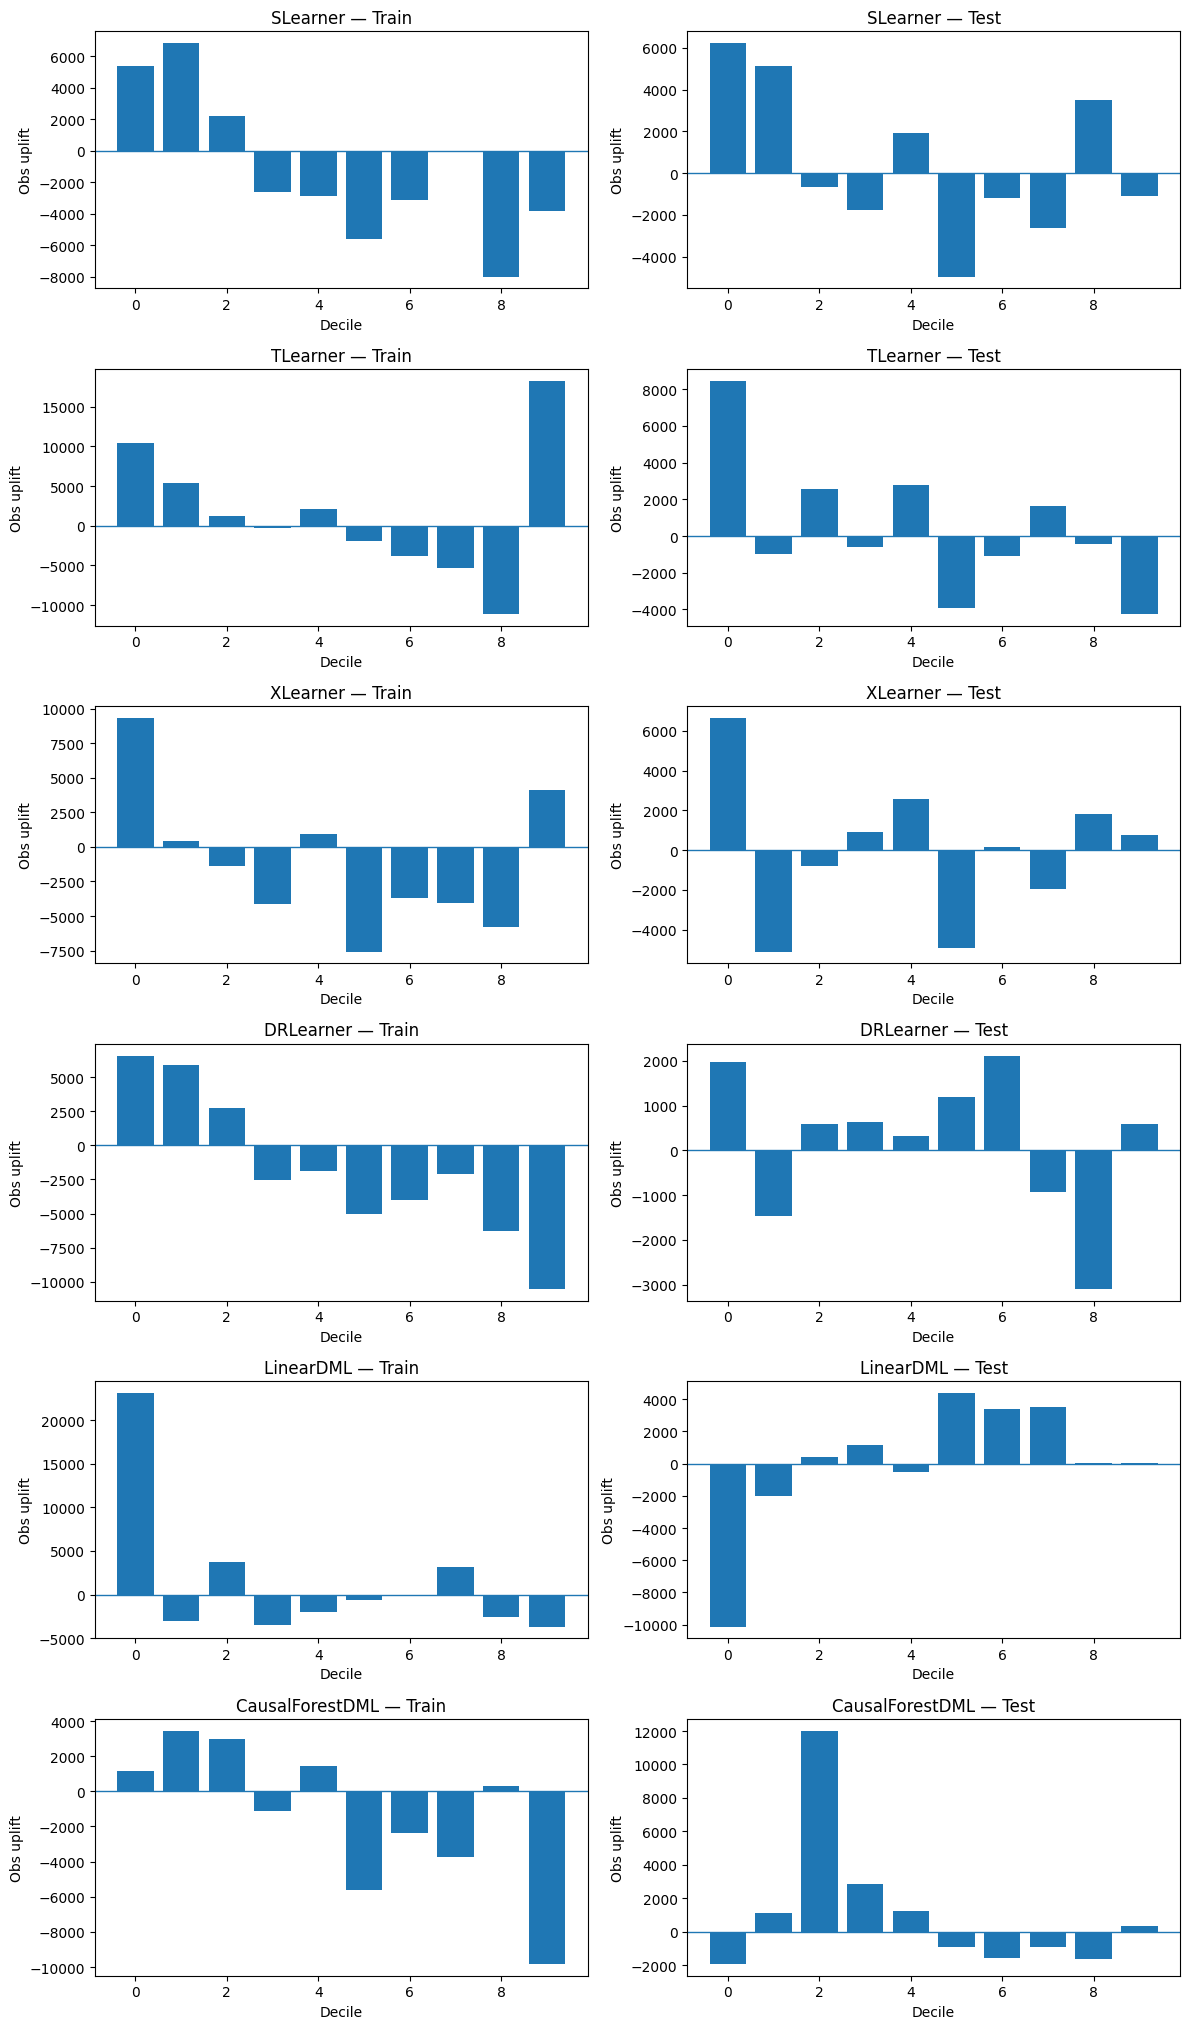

In [19]:

fig, axes = plt.subplots(len(models), 2, figsize=(12, 3.4 * len(models)))

for row_idx, (name, _) in enumerate(models.items()):
    train_df = uplift_by_decile(y_train, T_train, cate_train[name])
    test_df  = uplift_by_decile(y_test,  T_test,  cate_test[name])

    axes[row_idx, 0].bar(train_df["decile"], train_df["observed_uplift"])
    axes[row_idx, 0].axhline(0, linewidth=1)
    axes[row_idx, 0].set_title(f"{name} — Train")
    axes[row_idx, 0].set_xlabel("Decile")
    axes[row_idx, 0].set_ylabel("Obs uplift")

    axes[row_idx, 1].bar(test_df["decile"], test_df["observed_uplift"])
    axes[row_idx, 1].axhline(0, linewidth=1)
    axes[row_idx, 1].set_title(f"{name} — Test")
    axes[row_idx, 1].set_xlabel("Decile")
    axes[row_idx, 1].set_ylabel("Obs uplift")

plt.tight_layout()
plt.show()

## 9. Expected response (binary-treatment version)

In this work, expected response is used as a more decision-oriented metric.

### Intuition
For each person:
- the model recommends treatment if predicted uplift is positive,
- otherwise the model recommends control.

Because we only observe the outcome under the **actually assigned treatment**, we estimate how good the policy is with an **inverse-propensity-weighted policy value**:

 Expected Response = E[ Y × I(T = a(X)) / P(T | X) ]
    
    Where I(T = a(X)) is equal to 1, when treatment is actually assigned, else 0. 
In a randomized experiment with roughly constant assignment probability, this becomes straightforward to compute.


In [20]:

def expected_response_binary(y, t, uplift_scores, p_treat=None):
    y = np.asarray(y)
    t = np.asarray(t).astype(int)
    uplift_scores = np.asarray(uplift_scores).ravel()

    if p_treat is None:
        p_treat = t.mean()

    p_control = 1 - p_treat
    recommended_treatment = (uplift_scores > 0).astype(int)

    weight = np.where(recommended_treatment == 1, 1 / p_treat, 1 / p_control)
    observed_if_followed = (recommended_treatment == t).astype(int)

    return np.mean(y * observed_if_followed * weight)

In [21]:

metric_rows = []
for name in models:
    train_er = expected_response_binary(y_train, T_train, cate_train[name], p_treat=T_train.mean())
    test_er  = expected_response_binary(y_test,  T_test,  cate_test[name],  p_treat=T_test.mean())
    metric_rows.append({
        "Model": name,
        "ExpectedResponse_Train": train_er,
        "ExpectedResponse_Test": test_er
    })

expected_response_df = pd.DataFrame(metric_rows).sort_values("ExpectedResponse_Test", ascending=False)
expected_response_df

,Model,ExpectedResponse_Train,ExpectedResponse_Test
0,SLearner,10084.517560,9177.923448
1,TLearner,10047.760508,8225.655137
2,XLearner,9822.502760,8089.190804
5,CausalForestDML,8044.869124,7214.912195
3,DRLearner,8838.831954,5989.903949
4,LinearDML,5440.521197,4828.437861


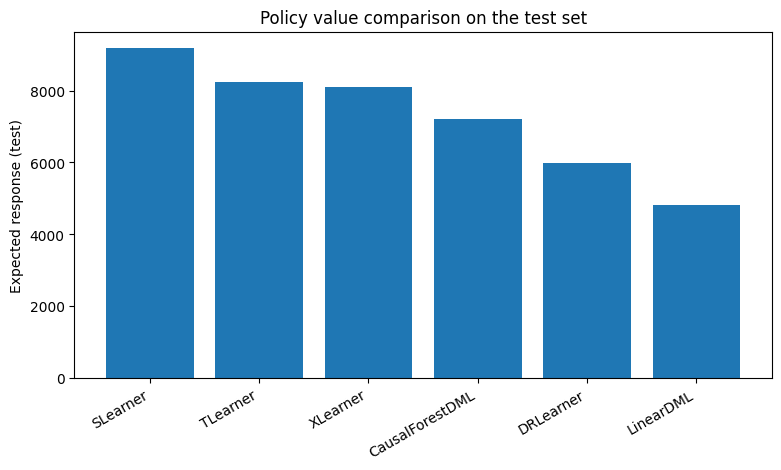

In [22]:

plt.figure(figsize=(9, 4.5))
plt.bar(expected_response_df["Model"], expected_response_df["ExpectedResponse_Test"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Expected response (test)")
plt.title("Policy value comparison on the test set")
plt.show()

## 10. Confidence intervals with Linear DML

One nice feature of `LinearDML` is that it can provide confidence intervals directly.


In [23]:

lb, ub = models["LinearDML"].effect_interval(X_test, T0=0, T1=1, alpha=0.05)

print("Lower bounds (first 5):", lb[:5])
print("Upper bounds (first 5):", ub[:5])

Lower bounds (first 5): [ -288.91205216  2458.50208897 -2216.77656149 -4170.36233339
 -3868.06794743]
Upper bounds (first 5): [11826.76064953 15199.26270957  9121.21299571  6301.91991069
  3160.24774699]


Lower bounds (first 5): [ -288.91205216  2458.50208897 -2216.77656149 -4170.36233339
     -3868.06794743]
    Upper bounds (first 5): [11826.76064953 15199.26270957  9121.21299571  6301.91991069
      3160.24774699]


In [24]:

intervals = np.column_stack([lb, ub])
contains_zero = np.mean(np.sign(intervals[:, 0]) != np.sign(intervals[:, 1]))

print("Fraction of test observations whose 95% CI contains 0:", round(float(contains_zero), 4))

Fraction of test observations whose 95% CI contains 0: 0.8534


Fraction of test observations whose 95% CI contains 0: 0.8534


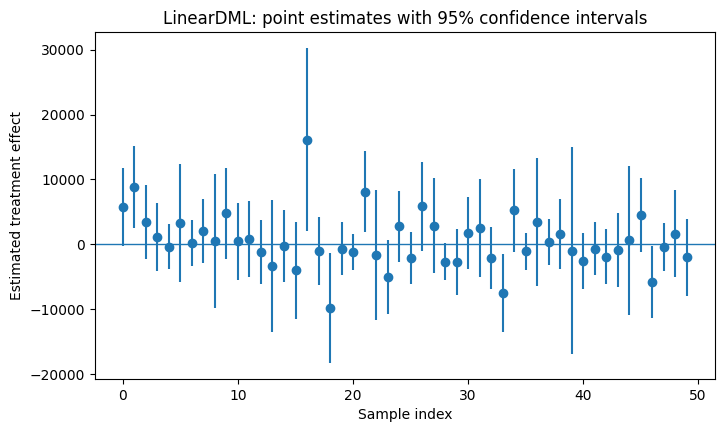

In [25]:

plt.figure(figsize=(8, 4.5))
sample_idx = np.arange(min(50, len(lb)))
plt.errorbar(
    sample_idx,
    cate_test["LinearDML"][:len(sample_idx)],
    yerr=[
        cate_test["LinearDML"][:len(sample_idx)] - lb[:len(sample_idx)],
        ub[:len(sample_idx)] - cate_test["LinearDML"][:len(sample_idx)]
    ],
    fmt='o'
)
plt.axhline(0, linewidth=1)
plt.title("LinearDML: point estimates with 95% confidence intervals")
plt.xlabel("Sample index")
plt.ylabel("Estimated treatment effect")
plt.show()

### Optional targeting rule
A very practical rule is:

- only target people whose estimated uplift is positive **and**
- whose interval does **not** include zero.

That gives you a more conservative treatment policy.


In [26]:

conservative_treat = (
    (np.asarray(cate_test["LinearDML"]).ravel() > 0) &
    (lb > 0)
).astype(int)

pd.Series(conservative_treat).value_counts(normalize=True).rename("share")

0    0.879479
1    0.120521
Name: share, dtype: float64

0    0.879479
    1    0.120521
    Name: share, dtype: float64


## 11. A compact comparison table

This is not the exact table from the book, but it serves the same purpose:
bring together practical aspects you might care about.


In [27]:

comparison = expected_response_df.merge(
    timing_df[["Model", "RelativeToFastest"]],
    on="Model",
    how="left"
).rename(columns={"RelativeToFastest": "RelativeComputeCost"})

comparison

,Model,ExpectedResponse_Train,ExpectedResponse_Test,RelativeComputeCost
0,SLearner,10084.517560,9177.923448,1.0
1,TLearner,10047.760508,8225.655137,1.2
2,XLearner,9822.502760,8089.190804,2.6
3,CausalForestDML,8044.869124,7214.912195,14.5
4,DRLearner,8838.831954,5989.903949,70.9
5,LinearDML,5440.521197,4828.437861,9.6


## 12. Extra: counterfactual explanations

The work ends with a short section on **counterfactual explanations**.

### Key idea
This is **not** about estimating the true causal effect in the world.
It is about asking:

> *What small change to the input would flip the model's decision?*

To demonstrate this we build on the uplift estimates from linear DML model:
1. take the estimated uplift from `LinearDML`,
2. convert it into a simple recommendation label:
   - `1` if the model recommends treatment,
   - `0` if the model recommends control,
3. use **DiCE** to find feature changes that would flip the recommendation.

This explains the **decision policy**, not the true data-generating mechanism.


In [28]:

# Create a recommendation label from the LinearDML uplift estimates
train_recommend = (np.asarray(cate_train["LinearDML"]).ravel() > 0).astype(int)
test_recommend  = (np.asarray(cate_test["LinearDML"]).ravel() > 0).astype(int)

recommend_train_df = X_train.copy()
recommend_train_df["recommend_treatment"] = train_recommend

recommend_test_df = X_test.copy()
recommend_test_df["recommend_treatment"] = test_recommend

recommend_train_df.head()

,age,educ,married,nodegree,re74,re75,race_hispan,race_white,recommend_treatment
19,26,12,0,0,0.000,0.000,False,False,0
52,18,11,0,1,0.000,0.000,False,False,1
296,28,13,0,0,5260.631,3790.113,False,True,1
37,23,12,1,0,0.000,0.000,False,False,1
369,18,10,0,1,0.000,1491.339,False,True,0


In [29]:

# Train a small interpretable recommendation model for DiCE
recommendation_model = LogisticRegression(max_iter=5000)
recommendation_model.fit(X_train, train_recommend)

print("Share recommended for treatment in train:", train_recommend.mean().round(3))
print("Share recommended for treatment in test :", test_recommend.mean().round(3))

Share recommended for treatment in train: 0.638
Share recommended for treatment in test : 0.642


Share recommended for treatment in train: 0.638
    Share recommended for treatment in test : 0.642


In [30]:

# DiCE setup
import dice_ml
from dice_ml import Dice

dice_data = dice_ml.Data(
    dataframe=recommend_train_df,
    continuous_features=["age", "educ", "re74", "re75"],
    outcome_name="recommend_treatment",
)

dice_model = dice_ml.Model(model=recommendation_model, backend="sklearn", model_type="classifier")
dice = Dice(dice_data, dice_model, method="random")

In [31]:

# Pick one person the policy currently does NOT recommend for treatment
candidate_pool = recommend_test_df.copy()
candidate_pool["pred"] = recommendation_model.predict(X_test)

query_idx = candidate_pool.index[candidate_pool["pred"] == 0][0]
query_instance = X_test.loc[[query_idx]]

query_instance

,age,educ,married,nodegree,re74,re75,race_hispan,race_white
372,17,10,0,1,0.0,1453.742,True,False


In [32]:

cf = dice.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_class="opposite",
    features_to_vary=["age", "educ", "re74", "re75", "married", "nodegree"]
)

cf.visualize_as_dataframe(show_only_changes=True)

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.61it/s]

Query instance (original outcome : 0)


,age,educ,married,nodegree,re74,re75,race_hispan,race_white,recommend_treatment
0,17,10,0,1,0.0,1453.741943,True,True,0



Diverse Counterfactual set (new outcome: 1)


,age,educ,married,nodegree,re74,re75,race_hispan,race_white,recommend_treatment
0,41,15,-,-,-,-,-,False,1
1,-,-,-,-,2584.0,-,-,False,1
2,-,-,-,0,21883.0,-,-,False,1


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.55it/s]

    Query instance (original outcome : 0)
    

    
    


    
    Diverse Counterfactual set (new outcome: 1)
    


### How to read the counterfactuals
Each row says something like:

> “If this person's features changed in these small ways, the **recommendation model** would flip from 'do not treat' to 'treat'.”

This is an explanation of the **policy model**, not a guarantee about the real world.

Again, this section is meant to explain **model behavior under the learned policy**, not to make a claim about ground-truth causal effects in the real world.

## 13. Practical takeaways

This analysis brings together several complementary pieces of modern CATE estimation:

- randomized-experiment sanity checks  
- S-, T-, X-, DR-, LinearDML-, and CausalForestDML-based estimators  
- fit-time comparison  
- uplift-by-decile evaluation  
- expected response / policy value  
- confidence intervals  
- counterfactual-style explanations  

The key practical differences in this setting are:

- we use a **public randomized dataset** (LaLonde) rather than a marketing campaign dataset  
- the setup is **binary treatment** rather than multi-treatment  
- the final interpretation section focuses on explaining the **learned recommendation policy** in this simpler setting  

Overall, the goal is not to reproduce a template, but to understand how these methods behave under a clean experimental design and what they offer for decision-making in practice.
